In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


####Load the Dataset

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### Check for Missing Values and Data Types

In [ ]:
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling 

In [ ]:
print("Blank values in TotalCharges:")
print((df["TotalCharges"].astype(str).str.strip() == "").sum())

Blank values in TotalCharges:
11


#### Summarize Key Statistics

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


### Visualize Important Relationships

#### Churn vs Contract

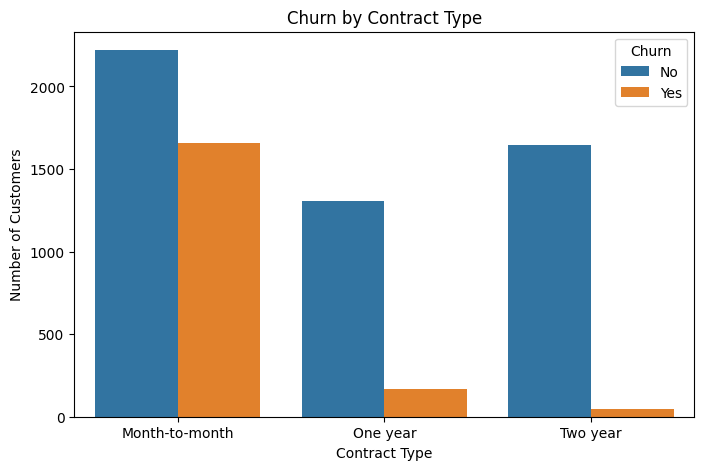

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

Customers with month-to-month contracts appear more likely to churn than customers with longer contracts. This suggests that long-term contracts may improve customer retention.

#### Monthly Charges vs Churn

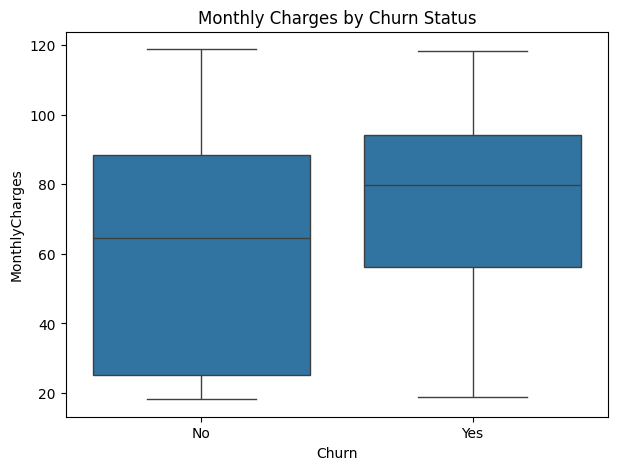

In [ ]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges by Churn Status")

plt.show()

Churn customers generally show higher monthly charges, suggesting that monthly cost may be an important factor in customer churn.

####Explore Churn Distribution

In [ ]:
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)


Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


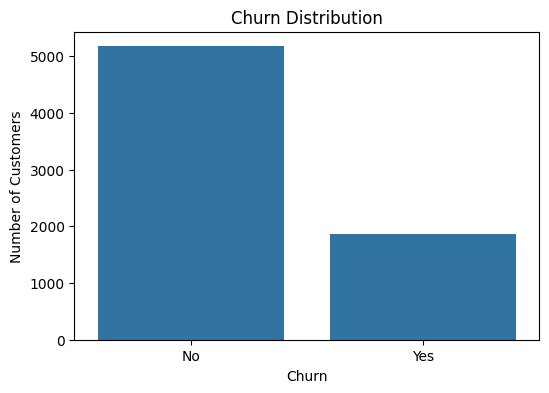

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Handle Missing or Blank Values in TotalCharges

In [ ]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [ ]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


#### Encode Categorical Features

In [ ]:
df = df.drop("customerID", axis=1)
X = df.drop("Churn", axis=1)
y = df["Churn"]
X = pd.get_dummies(X, drop_first=True, dtype=int)
y = y.map({
    "No": 0,
    "Yes": 1
})

#### Split the Data into Training and Testing Sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (5634, 30)
X_test shape: (1409, 30)


#### Scale Numerical Features

In [ ]:
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

X_test_scaled[numerical_features] = scaler.transform(
    X_test[numerical_features]
)
X_train_scaled.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,0,0.102371,-0.521976,-0.263289,1,0,0,0,1,0,...,0,1,0,1,0,0,0,0,1,0
3151,0,-0.711743,0.337478,-0.504814,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
4860,0,-0.793155,-0.809013,-0.751213,1,1,1,0,1,0,...,0,0,0,0,0,1,0,0,0,1
3867,0,-0.263980,0.284384,-0.173699,0,1,0,1,0,0,...,0,1,0,1,0,1,1,1,0,0
3810,0,-1.281624,-0.676279,-0.990851,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,1,0


# Part 2
####A. Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for classification. It predicts the probability that a customer belongs to a particular class, such as churn or non-churn.

The model uses a linear equation:

$$
z = wX + b
$$

The sigmoid function converts this value into a probability between 0 and 1:
$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$
	​


A probability greater than or equal to 0.5 is generally classified as churn.

#### Train Logistic Regression

In [ ]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(
    X_train_scaled,
    y_train
)

y_pred_log = log_model.predict(
    X_test_scaled
)

y_prob_log = log_model.predict_proba(
    X_test_scaled
)[:, 1]

### B. K-Nearest Neighbors (KNN)

KNN predicts the class of a new data point based on the classes of its nearest neighboring data points.

The process is:
*   Calculates the distance between the new point and training data.
*   Selects the K nearest neighbors.
*   Finds the majority class among those neighbors.
*   Predicts that class.

KNN is distance-based, so feature scaling is important. Features with larger numerical values could otherwise dominate the distance calculation.

Experiment with K = 3, 5, 7, 9

In [ ]:
k_values = [3, 5, 7, 9]

knn_results = []

for k in k_values:

    knn_model = KNeighborsClassifier(
        n_neighbors=k
    )

    knn_model.fit(
        X_train_scaled,
        y_train
    )

    y_pred = knn_model.predict(
        X_test_scaled
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    knn_results.append({
        "K": k,
        "Accuracy": accuracy
    })

#### Compare the Results

In [ ]:
knn_results_df = pd.DataFrame(knn_results)

knn_results_df

,K,Accuracy
0,3,0.760114
1,5,0.762952
2,7,0.770050
3,9,0.772889


In [ ]:
knn_results_df = pd.DataFrame(knn_results)

print(knn_results_df)

   K  Accuracy
0  3  0.760114
1  5  0.762952
2  7  0.770050
3  9  0.772889


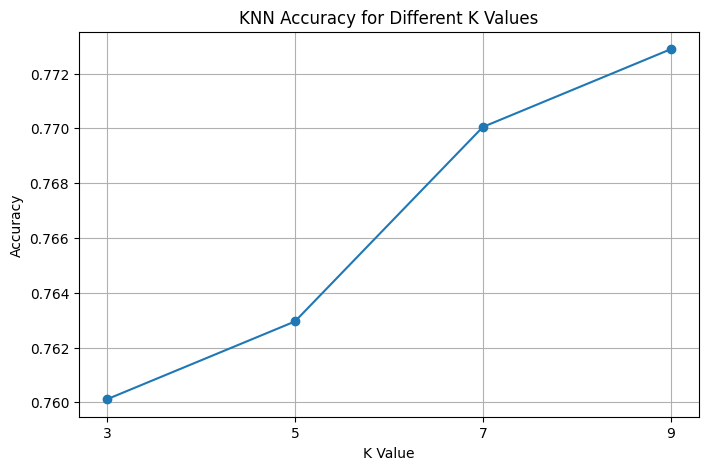

In [ ]:
#Visualization

plt.figure(figsize=(8, 5))
plt.plot(
    knn_results_df["K"],
    knn_results_df["Accuracy"],
    marker="o"
)
plt.title("KNN Accuracy for Different K Values")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.grid()
plt.show()

In [ ]:
#Select the Best K

best_k = knn_results_df.loc[
    knn_results_df["Accuracy"].idxmax(),
    "K"
]
print("Best K:", best_k)

Best K: 9


In [ ]:
# Train Final KNN Model

knn_model = KNeighborsClassifier(
    n_neighbors=best_k
)

knn_model.fit(
    X_train_scaled,
    y_train
)

y_pred_knn = knn_model.predict(
    X_test_scaled
)

y_prob_knn = knn_model.predict_proba(
    X_test_scaled
)[:, 1]

**KNN Interpretation**

A small K value can be sensitive to noise and may overfit. A larger K produces a smoother decision boundary but may become too general and underfit. Therefore, the best K is selected based on experimental performance.

**Scaling and Choice of K**

**Scaling:** KNN is a distance-based algorithm. Therefore, features with larger numerical ranges can dominate the distance calculation. Standard scaling is used to make the features comparable.

**Choice of K:** A small K can be sensitive to noise, while a large K can produce overly generalized predictions. The K value with the best accuracy is selected.

### C. Decision Tree

A Decision Tree works like a flowchart. It repeatedly splits the data using the most useful features until it reaches a final decision.

The process is:

*   Start with the complete dataset.
*   Select the best feature and split.
*   Create branches.
*   Repeat the process recursively.
*   Stop when the data is sufficiently separated or a stopping condition is reached.

Decision Trees are easy to interpret but can overfit. Hyperparameters such as max_depth and min_samples_leaf can control tree complexity.

In [ ]:
#Baseline Decision Tree
dt_baseline = DecisionTreeClassifier(
    random_state=42
)
dt_baseline.fit(
    X_train,
    y_train
)
y_pred_dt_baseline = dt_baseline.predict(
    X_test
)
print(
    "Baseline Accuracy:",
    accuracy_score(
        y_test,
        y_pred_dt_baseline
    )
)

Baseline Accuracy: 0.7416607523066004


In [ ]:
#Tune Decision Tree Using GridSearchCV
dt_param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_leaf": [1, 2, 5, 10]
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    param_grid=dt_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

dt_grid.fit(
    X_train,
    y_train
)

print(
    "Best Decision Tree Parameters:"
)

print(
    dt_grid.best_params_
)

print(
    "Best Cross-Validation F1 Score:",
    dt_grid.best_score_
)

Best Decision Tree Parameters:
{'max_depth': 7, 'min_samples_leaf': 2}
Best Cross-Validation F1 Score: 0.5435626388825657


In [ ]:
#Final Decision Tree
dt_model = dt_grid.best_estimator_
y_pred_dt = dt_model.predict(
    X_test
)
y_prob_dt = dt_model.predict_proba(
    X_test
)[:, 1]

### D. Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees.

Instead of relying on one tree:

*   Multiple trees are created.
*   Each tree is trained using a random sample of the data.
*   Each split considers a random subset of features.
*   Each tree votes for a class.
*   The majority vote becomes the final prediction.

Random Forest generally reduces the overfitting problem of a single Decision Tree but is less interpretable.


In [ ]:
#Baseline Random Forest
rf_baseline = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(
    X_train,
    y_train
)
y_pred_rf_baseline = rf_baseline.predict(
    X_test
)
print(
    "Baseline Accuracy:",
    accuracy_score(
        y_test,
        y_pred_rf_baseline
    )
)

Baseline Accuracy: 0.7863733144073811


In [ ]:
#Tune n_estimators, max_depth, and max_features
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "max_features": ["sqrt", "log2"]
}
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(
    X_train,
    y_train
)

print(
    "Best Random Forest Parameters:"
)

print(
    rf_grid.best_params_
)

print(
    "Best Cross-Validation F1 Score:",
    rf_grid.best_score_
)

Best Random Forest Parameters:
{'max_depth': 10, 'max_features': 'log2', 'n_estimators': 200}
Best Cross-Validation F1 Score: 0.5643089512348001


In [ ]:
#Final Random Forest
rf_model = rf_grid.best_estimator_

y_pred_rf = rf_model.predict(
    X_test
)

y_prob_rf = rf_model.predict_proba(
    X_test
)[:, 1]

### Compare Feature Importances

In [ ]:
dt_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

In [ ]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

In [ ]:
print("Top 10 Decision Tree Features")

print(
    dt_importance.head(10)
)

Top 10 Decision Tree Features
                               Feature  Importance
1                               tenure    0.366656
10         InternetService_Fiber optic    0.293950
3                         TotalCharges    0.088493
2                       MonthlyCharges    0.058057
28      PaymentMethod_Electronic check    0.030967
25                   Contract_Two year    0.022268
9                    MultipleLines_Yes    0.019427
12  OnlineSecurity_No internet service    0.016992
24                   Contract_One year    0.015354
14    OnlineBackup_No internet service    0.014288


In [ ]:
print("Top 10 Random Forest Features")

print(
    rf_importance.head(10)
)

Top 10 Random Forest Features
                           Feature  Importance
1                           tenure    0.175718
3                     TotalCharges    0.164976
2                   MonthlyCharges    0.113994
10     InternetService_Fiber optic    0.062935
25               Contract_Two year    0.062489
28  PaymentMethod_Electronic check    0.058986
13              OnlineSecurity_Yes    0.034260
24               Contract_One year    0.033072
19                 TechSupport_Yes    0.027327
26            PaperlessBilling_Yes    0.023829


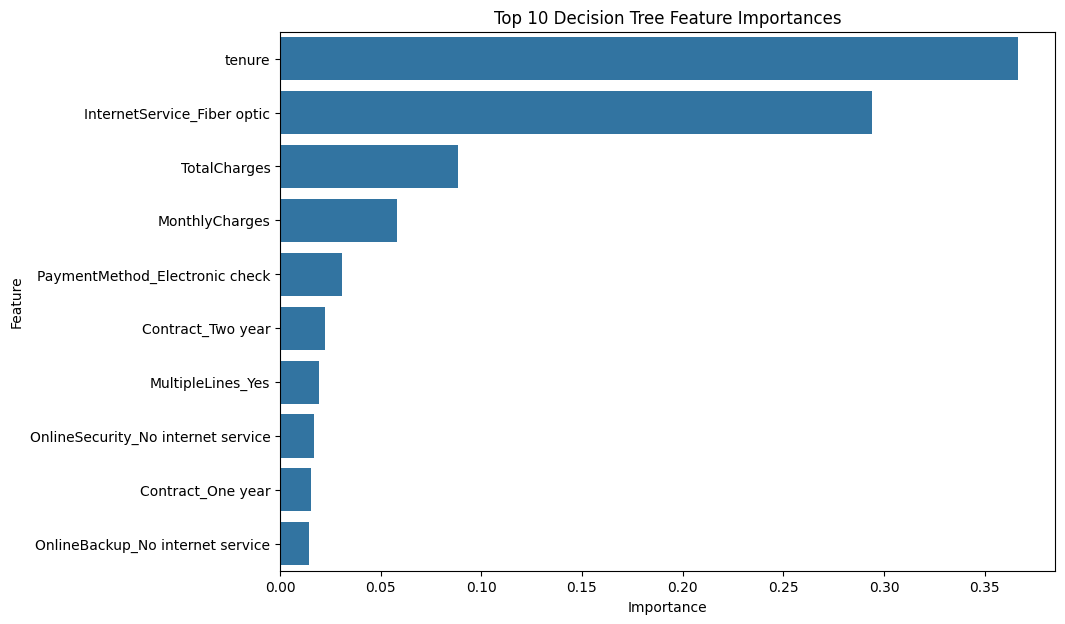

In [ ]:
#Decision Tree Feature Importance Plot
plt.figure(figsize=(10, 7))

sns.barplot(
    data=dt_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Decision Tree Feature Importances"
)

plt.show()

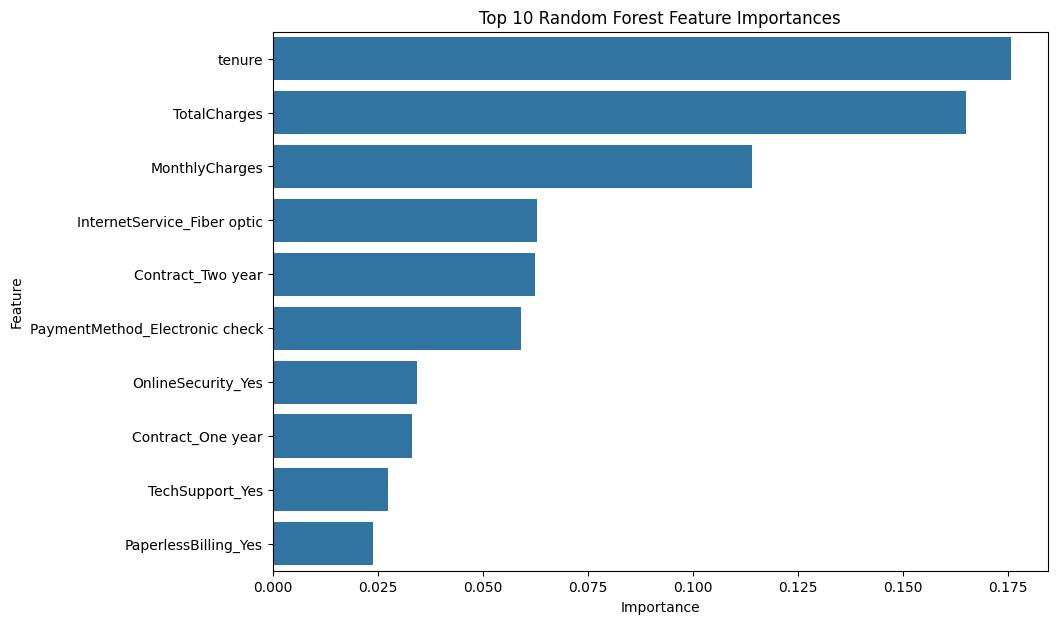

In [ ]:
#Random Forest Feature Importance Plot

plt.figure(figsize=(10, 7))
sns.barplot(
    data=rf_importance.head(10),
    x="Importance",
    y="Feature"
)
plt.title(
    "Top 10 Random Forest Feature Importances"
)
plt.show()

**Feature Importance Comparison**

The Decision Tree and Random Forest models identified several common important features, including tenure, TotalCharges, MonthlyCharges, InternetService_Fiber optic, Contract_Two year, and PaymentMethod_Electronic check. This indicates that these features consistently influence customer churn. In both models, tenure was the most important feature, suggesting that the length of the customer's relationship with the company strongly influences churn behavior. However, the Decision Tree calculates feature importance from a single tree and may depend strongly on specific splits. In contrast, Random Forest combines importance values from multiple decision trees, making its feature importance estimates more stable and robust.

#Part 3: Model Evaluation

In [ ]:
#Create Evaluation Function
def evaluate_model(
    model_name,
    y_true,
    y_pred,
    y_prob
):

    # Confusion Matrix
    cm = confusion_matrix(
        y_true,
        y_pred
    )

    # Extract TN, FP, FN, TP
    tn, fp, fn, tp = cm.ravel()

    # Calculate Metrics
    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_true,
        y_prob
    )

    # Print Results
    print("=" * 50)

    print(model_name)

    print("=" * 50)

    print("\nConfusion Matrix:")

    print(cm)

    print("\nTrue Negative (TN):", tn)
    print("False Positive (FP):", fp)
    print("False Negative (FN):", fn)
    print("True Positive (TP):", tp)

    print("\nAccuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("ROC-AUC:", auc)

    # Classification Report
    print("\nClassification Report:")

    print(
        classification_report(
            y_true,
            y_pred,
            zero_division=0
        )
    )

    # Confusion Matrix Plot
    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )

    plt.title(
        f"{model_name} - Confusion Matrix"
    )

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    return {
        "Model": model_name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": auc
    }

Logistic Regression

Confusion Matrix:
[[926 109]
 [165 209]]

True Negative (TN): 926
False Positive (FP): 109
False Negative (FN): 165
True Positive (TP): 209

Accuracy: 0.8055358410220014
Precision: 0.6572327044025157
Recall: 0.5588235294117647
F1 Score: 0.6040462427745664
ROC-AUC: 0.8420677361853834

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



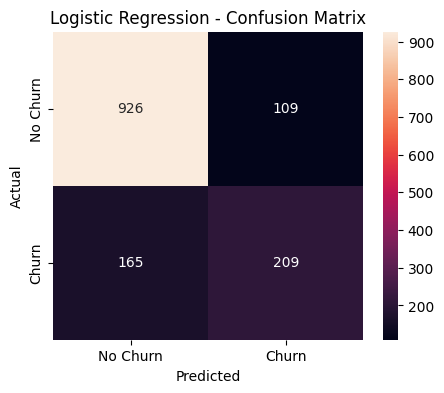

In [ ]:
#Evaluate Logistic Regression
log_results = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_log,
    y_prob_log
)

KNN (K=9)

Confusion Matrix:
[[877 158]
 [162 212]]

True Negative (TN): 877
False Positive (FP): 158
False Negative (FN): 162
True Positive (TP): 212

Accuracy: 0.772888573456352
Precision: 0.572972972972973
Recall: 0.5668449197860963
F1 Score: 0.5698924731182796
ROC-AUC: 0.8082978118783746

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      1035
           1       0.57      0.57      0.57       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409



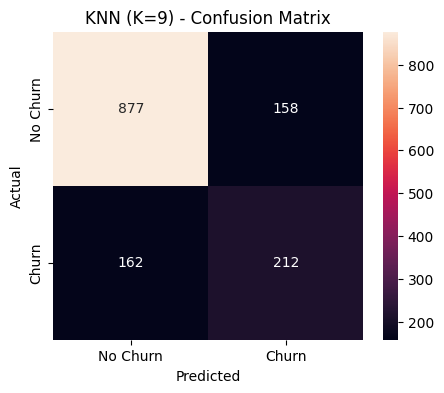

In [ ]:
#Evaluate KNN
knn_results_final = evaluate_model(
    f"KNN (K={best_k})",
    y_test,
    y_pred_knn,
    y_prob_knn
)

Decision Tree

Confusion Matrix:
[[913 122]
 [171 203]]

True Negative (TN): 913
False Positive (FP): 122
False Negative (FN): 171
True Positive (TP): 203

Accuracy: 0.7920511000709723
Precision: 0.6246153846153846
Recall: 0.5427807486631016
F1 Score: 0.580829756795422
ROC-AUC: 0.8133237748327262

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



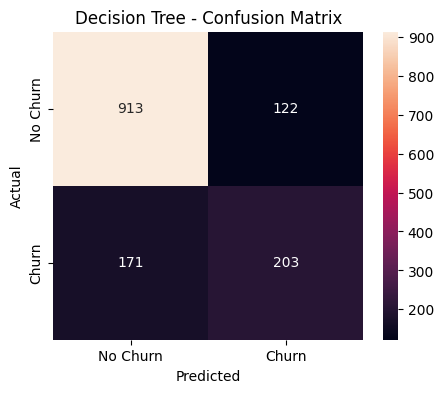

In [ ]:
#Evaluate Decision Tree
dt_results = evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_dt,
    y_prob_dt
)

Random Forest

Confusion Matrix:
[[943  92]
 [182 192]]

True Negative (TN): 943
False Positive (FP): 92
False Negative (FN): 182
True Positive (TP): 192

Accuracy: 0.8055358410220014
Precision: 0.676056338028169
Recall: 0.5133689839572193
F1 Score: 0.5835866261398176
ROC-AUC: 0.8413443901934952

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.68      0.51      0.58       374

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



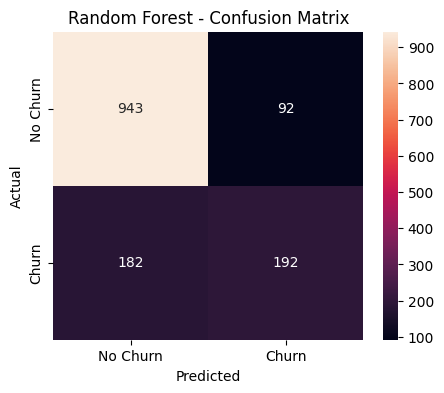

In [ ]:
#Evaluate Random Forest
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)

In [ ]:
#ROC Curves
models_for_roc = {
    "Logistic Regression": y_prob_log,
    f"KNN (K={best_k})": y_prob_knn,
    "Decision Tree": y_prob_dt,
    "Random Forest": y_prob_rf
}

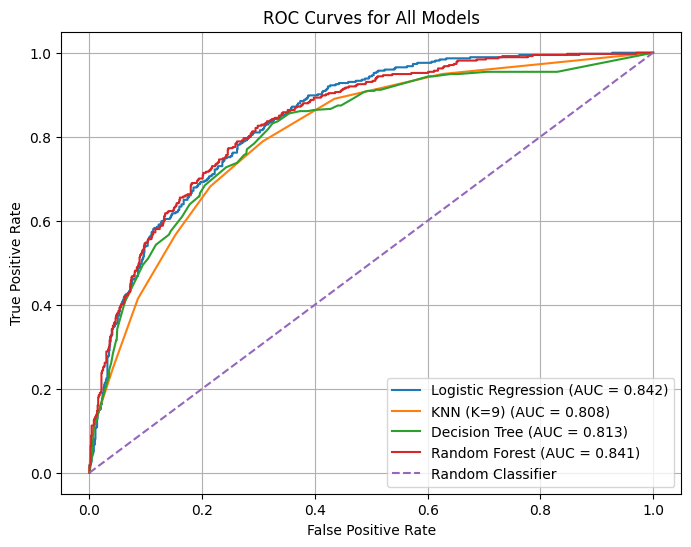

In [ ]:
plt.figure(figsize=(8, 6))
for name, y_prob in models_for_roc.items():
    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )
    auc = roc_auc_score(
        y_test,
        y_prob
    )
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )
# Random Classifier Line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)
plt.title(
    "ROC Curves for All Models"
)
plt.xlabel(
    "False Positive Rate"
)
plt.ylabel(
    "True Positive Rate"
)
plt.legend()
plt.grid()
plt.show()

**ROC-AUC Interpretation**

The ROC curve shows the relationship between the:
*   True Positive Rate
*   False Positive Rate

The ideal ROC curve moves toward the top-left corner. The diagonal line represents random classification. A higher ROC-AUC indicates better ability to distinguish churn customers from non-churn customers across different classification thresholds.

In [ ]:
#Performance Summary Table
results = [
    log_results,
    knn_results_final,
    dt_results,
    rf_results
]
summary_df = pd.DataFrame(
    results
)

In [ ]:
summary_df = summary_df[
    [
        "Model",
        "TN",
        "FP",
        "FN",
        "TP",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
]

In [ ]:
summary_df = summary_df.sort_values(
    by="F1 Score",
    ascending=False
)
summary_df

,Model,TN,FP,FN,TP,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,926,109,165,209,0.805536,0.657233,0.558824,0.604046,0.842068
3,Random Forest,943,92,182,192,0.805536,0.676056,0.513369,0.583587,0.841344
2,Decision Tree,913,122,171,203,0.792051,0.624615,0.542781,0.580830,0.813324
1,KNN (K=9),877,158,162,212,0.772889,0.572973,0.566845,0.569892,0.808298


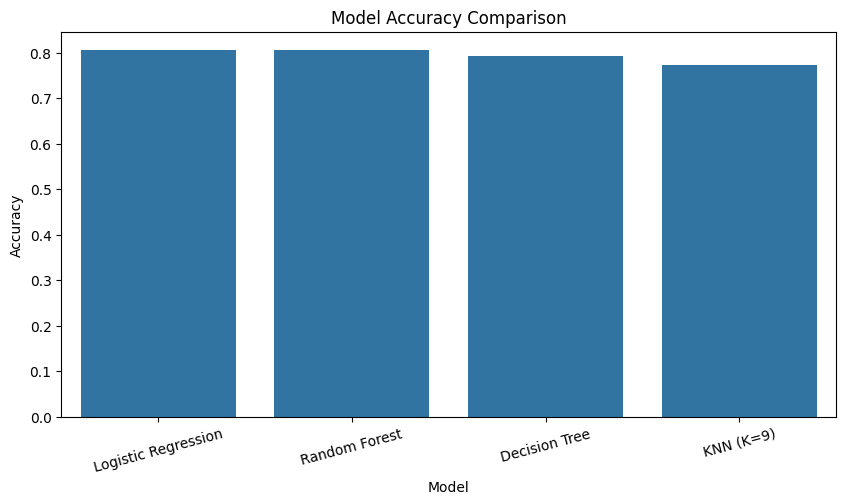

In [ ]:
#Visualize Model Comparison
plt.figure(figsize=(10, 5))
sns.barplot(
    data=summary_df,
    x="Model",
    y="Accuracy"
)
plt.title(
    "Model Accuracy Comparison"
)
plt.xticks(
    rotation=15
)
plt.show()

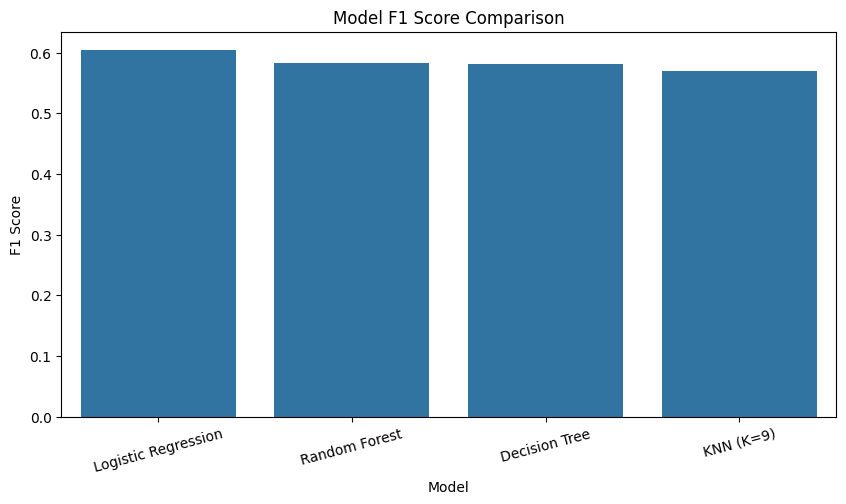

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=summary_df,
    x="Model",
    y="F1 Score"
)
plt.title(
    "Model F1 Score Comparison"
)
plt.xticks(
    rotation=15
)
plt.show()

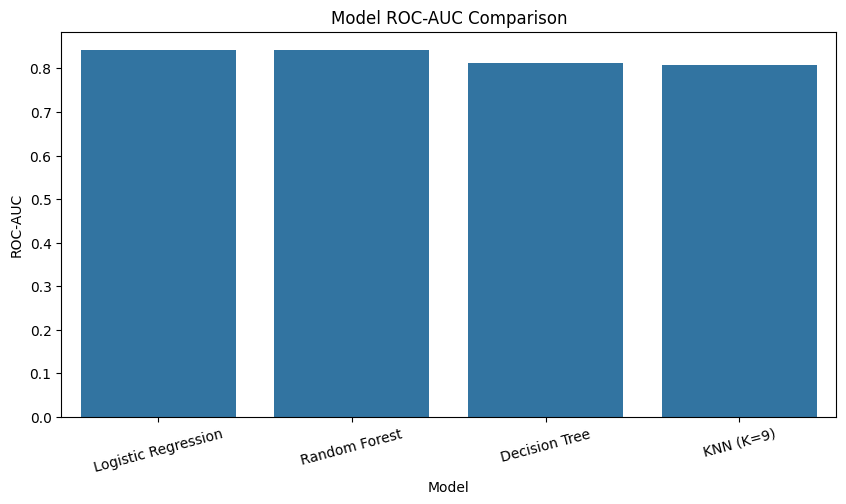

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=summary_df,
    x="Model",
    y="ROC-AUC"
)
plt.title(
    "Model ROC-AUC Comparison"
)
plt.xticks(
    rotation=15
)
plt.show()

### Which Model Performs Best Overall?

In [ ]:
best_accuracy_model = summary_df.loc[
    summary_df["Accuracy"].idxmax(),
    "Model"
]

best_f1_model = summary_df.loc[
    summary_df["F1 Score"].idxmax(),
    "Model"
]

best_auc_model = summary_df.loc[
    summary_df["ROC-AUC"].idxmax(),
    "Model"
]

print(
    "Best Accuracy:",
    best_accuracy_model
)

print(
    "Best F1 Score:",
    best_f1_model
)

print(
    "Best ROC-AUC:",
    best_auc_model
)

Best Accuracy: Logistic Regression
Best F1 Score: Logistic Regression
Best ROC-AUC: Logistic Regression


Based on the experimental results, Logistic Regression performed best overall because it achieved the highest Accuracy, F1 Score, and ROC-AUC score among all tested models. Therefore, it provided the best overall predictive performance for this customer churn prediction problem. In addition, Logistic Regression is easier to interpret than more complex models, making it a practical choice for deployment.

# **Precision or Recall: Which Is More Important?**

Answer:

Recall is generally more important for customer churn prediction.

In this problem, a False Negative occurs when a customer who will actually churn is predicted as a non-churn customer. The company then misses the opportunity to contact the customer with a retention offer, which may result in the permanent loss of that customer and future revenue.

A False Positive occurs when the model predicts that a customer will churn even though the customer would actually stay. This may result in an unnecessary retention offer, creating an additional business cost.

Therefore, missing a customer who is truly going to churn can be more harmful than contacting a customer who eventually stays. For this reason, recall is prioritized.

However, precision should not be ignored. If precision is too low, the company may spend excessive resources on customers who were never likely to churn. Therefore, the ideal approach is to prioritize recall while maintaining a reasonable balance using F1 score and considering the business cost of retention campaigns.

# **Trade-Off Between Interpretability and Performance**
**Logistic Regression:**
*   Highly interpretable.
*   The relationship between features and predictions is easier to understand.
*   May perform well but can have difficulty modeling complex relationships.

**KNN:**
*   Simple and easy to understand.
*   Performance depends strongly on feature scaling and the choice of K.
*   Can be computationally expensive for large datasets.

**Decision Tree**
*   Can overfit if the tree becomes too deep.
*   Highly interpretable and easy to visualize.
*   Decision rules are easy to explain.

**Random Forest**


*   Usually provides stronger predictive performance.
*   Reduces the overfitting problem compared with a single Decision Tree.
*   More difficult to interpret because it consists of many trees.



**Overall Trade-Off**

More interpretable models, such as Logistic Regression and Decision Trees, are easier to explain to business stakeholders. More complex models, such as Random Forest, may provide stronger performance but have lower interpretability. The final model should therefore balance predictive performance and interpretability.

# Part 4 - Insights and Conclusion


# Key Factors Influencing Customer Churn

The feature importance analysis identified several important factors associated with customer churn. Both the Decision Tree and Random Forest models consistently identified tenure, TotalCharges, MonthlyCharges, InternetService_Fiber optic, Contract_Two year, and PaymentMethod_Electronic check as important predictors of churn.

Among these features, tenure was the most important feature in both models. This suggests that the length of the customer's relationship with the company has a strong influence on churn behavior. Customers' TotalCharges and MonthlyCharges were also important, indicating that customer spending and service costs are associated with the likelihood of churn.

InternetService_Fiber optic, Contract_Two year, and PaymentMethod_Electronic check were also identified as important features. The presence of similar important features in both models indicates that these variables consistently contribute to churn prediction.

The Decision Tree assigned a larger importance value to a small number of features, especially tenure and InternetService_Fiber optic. In contrast, the Random Forest distributed feature importance more evenly across multiple features. Since Random Forest calculates feature importance by combining information from multiple trees, its importance estimates are generally more stable and robust.

# Recommended Model for Deployment

Based on the experimental results, Logistic Regression is recommended for deployment.

The results showed that Logistic Regression achieved the highest Accuracy (80.55%), the highest F1 Score (60.40%), and the highest ROC-AUC score (84.21%) among all tested models. It also achieved the same highest accuracy as the Random Forest model, while outperforming it in F1 Score and ROC-AUC.

Logistic Regression also provides a high level of interpretability compared with more complex models. The model is computationally efficient and allows the relationship between input features and churn probability to be more easily understood.

Therefore, Logistic Regression provides the best overall balance between predictive performance, model simplicity, and interpretability and is the recommended model for this customer churn prediction problem.

# Business Implications of False Positives and False Negatives

In customer churn prediction, the consequences of False Positives and False Negatives are different.

A False Positive (FP) occurs when the model predicts that a customer will churn, but the customer actually remains with the company. In this case, the company may provide an unnecessary retention offer, discount, or other incentive. This can increase business costs.

A False Negative (FN) occurs when the model predicts that a customer will not churn, but the customer actually leaves the company. This is generally more harmful because the company misses the opportunity to take retention action and may permanently lose the customer's future revenue.

Therefore, False Negatives are generally more costly than False Positives in the customer churn problem. For this reason, recall is an important metric because it measures how effectively the model identifies customers who actually churn.

However, precision should also be considered. If precision is too low, the company may spend too many resources on customers who were not actually at risk of leaving. Therefore, the most practical approach is to prioritize recall while maintaining a reasonable balance between precision and recall.

# Limitations and Potential Improvements

This approach has several limitations.

First, the dataset may not contain all factors that influence customer churn. Important information such as customer satisfaction, complaint history, service quality, competitor offers, and customer interaction history could potentially improve prediction performance.

Second, the dataset contains more non-churn customers than churn customers. This class imbalance may affect the performance of the models and make accuracy alone insufficient for evaluation.

Third, the models generally use the default classification threshold of 0.5. In a real business environment, this threshold could be adjusted based on the cost of False Positives and False Negatives. A lower threshold, for example, could potentially identify more customers who are at risk of churn and improve recall.

Fourth, although GridSearchCV was used to tune the Decision Tree and Random Forest models, only selected hyperparameter values were tested. A broader hyperparameter search could potentially improve model performance.

Finally, the models were evaluated using a single train-test split. Using repeated cross-validation or additional validation datasets could provide a more reliable estimate of model performance.

Potential improvements include:


*   Collecting additional customer behavioral and service-related features.
*   Applying techniques such as class weighting or SMOTE to address class imbalance.
*   Optimizing the classification threshold based on business costs.
*   Performing a broader hyperparameter search.
*   Using repeated cross-validation for more reliable evaluation.
*   Testing additional machine learning algorithms such as Gradient Boosting or XGBoost.
*   Using cost-sensitive learning to account for the different costs of False Positives and False Negatives.

# Final Conclusion

This project applied and compared Logistic Regression, K-Nearest Neighbors, Decision Tree, and Random Forest to predict customer churn. The models were evaluated using the confusion matrix, Accuracy, Precision, Recall, F1 Score, ROC Curve, and ROC-AUC score.

The results showed that Logistic Regression performed best overall, achieving the highest Accuracy, F1 Score, and ROC-AUC score. It also provides better interpretability than more complex models, making it suitable for practical business deployment.

The feature importance analysis identified tenure, TotalCharges, MonthlyCharges, InternetService_Fiber optic, Contract_Two year, and PaymentMethod_Electronic check as important factors associated with customer churn.

The analysis also showed that False Negatives are particularly important because failing to identify a customer who is likely to churn may result in customer and revenue loss. Therefore, recall should be given particular attention while maintaining a reasonable balance with precision.

Overall, the project demonstrates that machine learning can help telecom companies identify customers who are likely to churn. The model can support targeted retention strategies and enable the company to take action before high-risk customers leave. Further improvements in data collection, class imbalance handling, threshold optimization, and model tuning could potentially improve the performance of the churn prediction system.